# RxRx1 exploratory data analysis and proxy dataset construction

This notebook has four goals:

1. Validate the metadata and dataset hierarchy.
2. Characterize class balance, cell-type composition, plate coverage, and intensity shifts.
3. Visualize the six fluorescence channels and representative technical variation.
4. Construct four logical proxy datasets backed by one shared pool of original 512×512 PNG images.

The notebook is designed for Kaggle. The full image export is disabled by default so that Run All does not accidentally start a long, disk-intensive job.

Dataset reference: [RxRx1 official overview](https://www.kaggle.com/c/recursion-cellular-image-classification/overview).

In [29]:
from collections import defaultdict
from pathlib import Path
import hashlib
import json
import platform
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

SEED = 42
N_PROXY_SIRNA = 400
N_FULL_SIRNA = 1108
IMAGE_SIZE = 512

DATASET_PATH = Path('/kaggle/input/competitions/recursion-cellular-image-classification')
TRAIN_IMAGE_DIR = DATASET_PATH / "train"

D1_EXPERIMENT_COUNTS = {
    "HEPG2": 2,
    "HUVEC": 4,
    "RPE": 2,
    "U2OS": 1,
}
D4_CELL_TYPES = ("HUVEC", "HEPG2")

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", context="notebook")

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Dataset root:", DATASET_PATH)


Python: 3.12.13
pandas: 2.3.3
NumPy: 2.0.2
OpenCV: 4.13.0
Dataset root: /kaggle/input/competitions/recursion-cellular-image-classification


## 1. Load metadata

Only known metadata files are loaded. This avoids silently treating an unrelated CSV as part
of the analysis and makes schema failures explicit.

In [30]:
REQUIRED_METADATA_FILES = {
    "train": "train.csv",
    "test": "test.csv",
    "train_controls": "train_controls.csv",
    "test_controls": "test_controls.csv",
    "pixel_stats": "pixel_stats.csv",
    "sample_submission": "sample_submission.csv",
}

required_paths = {
    name: DATASET_PATH / filename
    for name, filename in REQUIRED_METADATA_FILES.items()
}

missing_paths = [
    str(path) for path in required_paths.values() if not path.exists()
]
if missing_paths:
    raise FileNotFoundError(
        "Required Kaggle files are missing:\n" + "\n".join(missing_paths)
    )

metadata = {
    name: pd.read_csv(path)
    for name, path in required_paths.items()
}

train = metadata["train"].copy()
test = metadata["test"].copy()
controls = metadata["train_controls"].copy()
test_controls = metadata["test_controls"].copy()
pixel_stats = metadata["pixel_stats"].copy()

for frame in (train, test, controls, test_controls):
    frame["cell_type"] = frame["experiment"].str.rsplit("-", n=1).str[0]

overview_rows = []
for name, frame in metadata.items():
    overview_rows.append(
        {
            "table": name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "memory_mib": frame.memory_usage(deep=True).sum() / (1024 ** 2),
            "missing_cells": int(frame.isna().sum().sum()),
            "duplicate_rows": int(frame.duplicated().sum()),
        }
    )

metadata_overview = pd.DataFrame(overview_rows).sort_values("table")
display(metadata_overview)
display(train.head())


,table,rows,columns,memory_mib,missing_cells,duplicate_rows
4,pixel_stats,753084,11,170.170635,0,0
5,sample_submission,19899,2,2.285833,0,0
1,test,19899,4,3.394957,0,0
3,test_controls,2246,6,0.646915,0,0
0,train,36517,5,8.253450,0,0
2,train_controls,4097,6,1.180231,0,0


,id_code,experiment,plate,well,sirna,cell_type
0,HEPG2-01_1_B03,HEPG2-01,1,B03,sirna_250,HEPG2
1,HEPG2-01_1_B04,HEPG2-01,1,B04,sirna_62,HEPG2
2,HEPG2-01_1_B05,HEPG2-01,1,B05,sirna_1115,HEPG2
3,HEPG2-01_1_B06,HEPG2-01,1,B06,sirna_602,HEPG2
4,HEPG2-01_1_B07,HEPG2-01,1,B07,sirna_529,HEPG2


## 2. Schema and integrity checks

These checks detect problems that a single total missing-value count would miss: duplicated
identifiers, malformed wells, unexpected plate or channel values, and train/test experiment
overlap.

In [31]:
REQUIRED_COLUMNS = {
    "train": {"id_code", "experiment", "plate", "well", "sirna"},
    "test": {"id_code", "experiment", "plate", "well"},
    "train_controls": {
        "id_code", "experiment", "plate", "well", "sirna", "well_type"
    },
    "test_controls": {
        "id_code", "experiment", "plate", "well", "sirna", "well_type"
    },
    "pixel_stats": {
        "id_code", "experiment", "plate", "well", "site", "channel",
        "mean", "std", "median", "min", "max"
    },
    "sample_submission": {"id_code", "sirna"},
}

for name, required in REQUIRED_COLUMNS.items():
    missing_columns = required - set(metadata[name].columns)
    assert not missing_columns, f"{name} is missing columns: {sorted(missing_columns)}"

key_specs = {
    "train": ["id_code"],
    "test": ["id_code"],
    "train_controls": ["id_code"],
    "test_controls": ["id_code"],
    "pixel_stats": ["id_code", "channel"],
    "sample_submission": ["id_code"],
}

quality_rows = []
for name, key_columns in key_specs.items():
    frame = metadata[name]
    quality_rows.append(
        {
            "table": name,
            "key": ", ".join(key_columns),
            "duplicate_keys": int(frame.duplicated(key_columns).sum()),
            "missing_cells": int(frame.isna().sum().sum()),
        }
    )

quality_report = pd.DataFrame(quality_rows)
display(quality_report)

missing_by_column = (
    pd.concat(
        {
            name: frame.isna().sum()
            for name, frame in metadata.items()
        },
        names=["table", "column"],
    )
    .rename("missing")
    .reset_index()
    .query("missing > 0")
)

if missing_by_column.empty:
    print("PASS: no missing metadata values were found.")
else:
    display(missing_by_column)

train_experiments = set(train["experiment"])
test_experiments = set(test["experiment"])

assert train_experiments.isdisjoint(test_experiments), (
    "Train and test experiments overlap; batch generalization assumptions are invalid."
)
assert train["sirna"].nunique() == N_FULL_SIRNA
assert train["plate"].between(1, 4).all()
assert test["plate"].between(1, 4).all()
assert pixel_stats["channel"].between(1, 6).all()

for name, frame in {
    "train": train,
    "test": test,
    "train_controls": controls,
    "test_controls": test_controls,
}.items():
    valid_wells = frame["well"].astype(str).str.fullmatch(r"[A-P]\d{2}")
    assert valid_wells.all(), f"Malformed well identifiers were found in {name}."

print("PASS: schemas, keys, plate values, channel values, and well formats are valid.")
print("PASS: train and test experiments are disjoint.")


,table,key,duplicate_keys,missing_cells
0,train,id_code,0,0
1,test,id_code,0,0
2,train_controls,id_code,0,0
3,test_controls,id_code,0,0
4,pixel_stats,"id_code, channel",0,0
5,sample_submission,id_code,0,0


PASS: no missing metadata values were found.
PASS: schemas, keys, plate values, channel values, and well formats are valid.
PASS: train and test experiments are disjoint.


## 3. Dataset composition and experiment completeness

Experiment counts and proportions are shown separately. The original notebook normalized the
values but labelled the axis as a count, which could lead to an incorrect interpretation.

,train_experiments,test_experiments,train_proportion,test_proportion
cell_type,,,,
HEPG2,7,4,0.212121,0.222222
HUVEC,16,8,0.484848,0.444444
RPE,7,4,0.212121,0.222222
U2OS,3,2,0.090909,0.111111


,cell_type,experiment,treatment_wells,unique_sirnas,plates,complete_1108
0,HEPG2,HEPG2-01,1106,1106,4,False
1,HEPG2,HEPG2-02,1106,1106,4,False
2,HEPG2,HEPG2-03,1108,1108,4,True
3,HEPG2,HEPG2-04,1108,1108,4,True
4,HEPG2,HEPG2-05,1108,1108,4,True
5,HEPG2,HEPG2-06,1108,1108,4,True
6,HEPG2,HEPG2-07,1106,1106,4,False
7,HUVEC,HUVEC-01,1108,1108,4,True
8,HUVEC,HUVEC-02,1108,1108,4,True
9,HUVEC,HUVEC-03,1108,1108,4,True


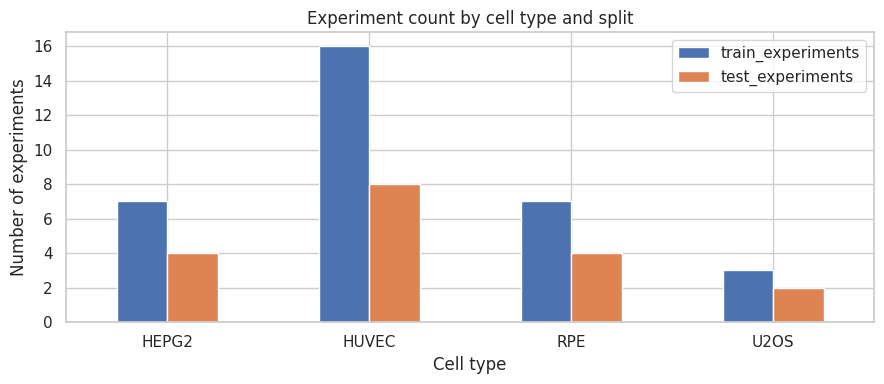

,complete_experiments,total_experiments
cell_type,,
HEPG2,4,7
HUVEC,12,16
RPE,6,7
U2OS,3,3


In [32]:
experiment_summary = (
    train.groupby(["cell_type", "experiment"])
    .agg(
        treatment_wells=("id_code", "size"),
        unique_sirnas=("sirna", "nunique"),
        plates=("plate", "nunique"),
    )
    .reset_index()
    .sort_values(["cell_type", "experiment"])
)
experiment_summary["complete_1108"] = (
    experiment_summary["unique_sirnas"] == N_FULL_SIRNA
)

split_composition = pd.DataFrame(
    {
        "train_experiments": train.groupby("cell_type")["experiment"].nunique(),
        "test_experiments": test.groupby("cell_type")["experiment"].nunique(),
    }
).fillna(0).astype(int)

split_composition["train_proportion"] = (
    split_composition["train_experiments"]
    / split_composition["train_experiments"].sum()
)
split_composition["test_proportion"] = (
    split_composition["test_experiments"]
    / split_composition["test_experiments"].sum()
)

display(split_composition)
display(experiment_summary)

ax = split_composition[["train_experiments", "test_experiments"]].plot(
    kind="bar",
    figsize=(9, 4),
    rot=0,
    title="Experiment count by cell type and split",
)
ax.set_xlabel("Cell type")
ax.set_ylabel("Number of experiments")
plt.tight_layout()
plt.show()

completeness = (
    experiment_summary.groupby("cell_type")["complete_1108"]
    .agg(complete_experiments="sum", total_experiments="count")
)
display(completeness)


## 4. Target balance and control composition

Plotting one bar for each of 1,108 siRNAs is difficult to read. A distribution of per-class
sample counts makes imbalance visible without hiding small differences in a dense chart.
Treatment labels and control labels are analyzed separately because they serve different roles.

,samples_per_sirna
count,1108.000000
mean,32.957581
std,0.256807
min,29.000000
25%,33.000000
50%,33.000000
75%,33.000000
max,33.000000


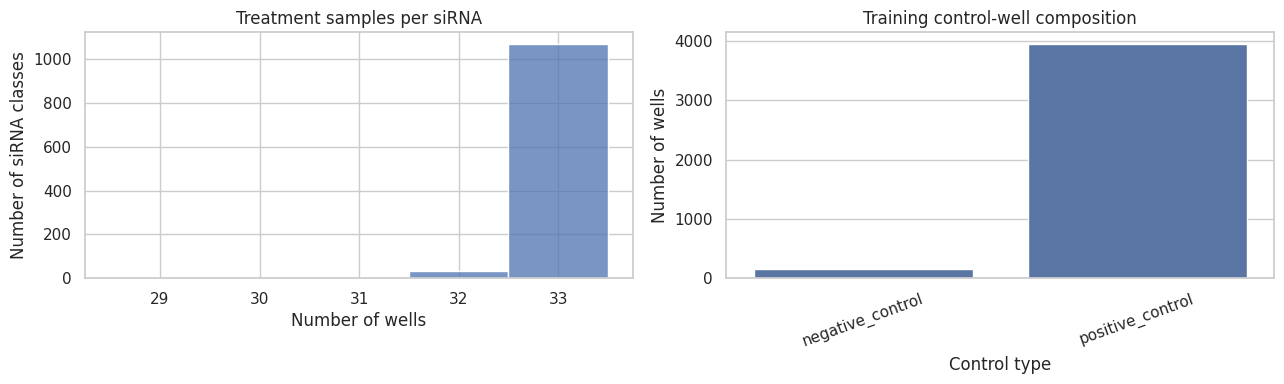

,count,mean,std,min,25%,50%,75%,max
well_type,,,,,,,,
negative_control,1.0,153.000000,NaN,153.0,153.0,153.0,153.0,153.0
positive_control,30.0,131.466667,0.860366,128.0,131.0,132.0,132.0,132.0


In [33]:
treatment_class_counts = train["sirna"].value_counts()
class_balance_summary = treatment_class_counts.describe().to_frame("samples_per_sirna")
display(class_balance_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(treatment_class_counts, discrete=True, ax=axes[0])
axes[0].set_title("Treatment samples per siRNA")
axes[0].set_xlabel("Number of wells")
axes[0].set_ylabel("Number of siRNA classes")

control_type_counts = controls["well_type"].value_counts().sort_index()
sns.barplot(
    x=control_type_counts.index,
    y=control_type_counts.values,
    ax=axes[1],
)
axes[1].set_title("Training control-well composition")
axes[1].set_xlabel("Control type")
axes[1].set_ylabel("Number of wells")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

control_label_summary = (
    controls.groupby(["well_type", "sirna"])
    .size()
    .rename("wells")
    .reset_index()
    .groupby("well_type")["wells"]
    .describe()
)
display(control_label_summary)


## 5. Plate coverage

Each treatment siRNA is assigned to one well per experiment, distributed across four plates.
Therefore a plate should contain only a subset of the 1,108 classes; completeness must be
evaluated at the experiment level, not at the individual-plate level.

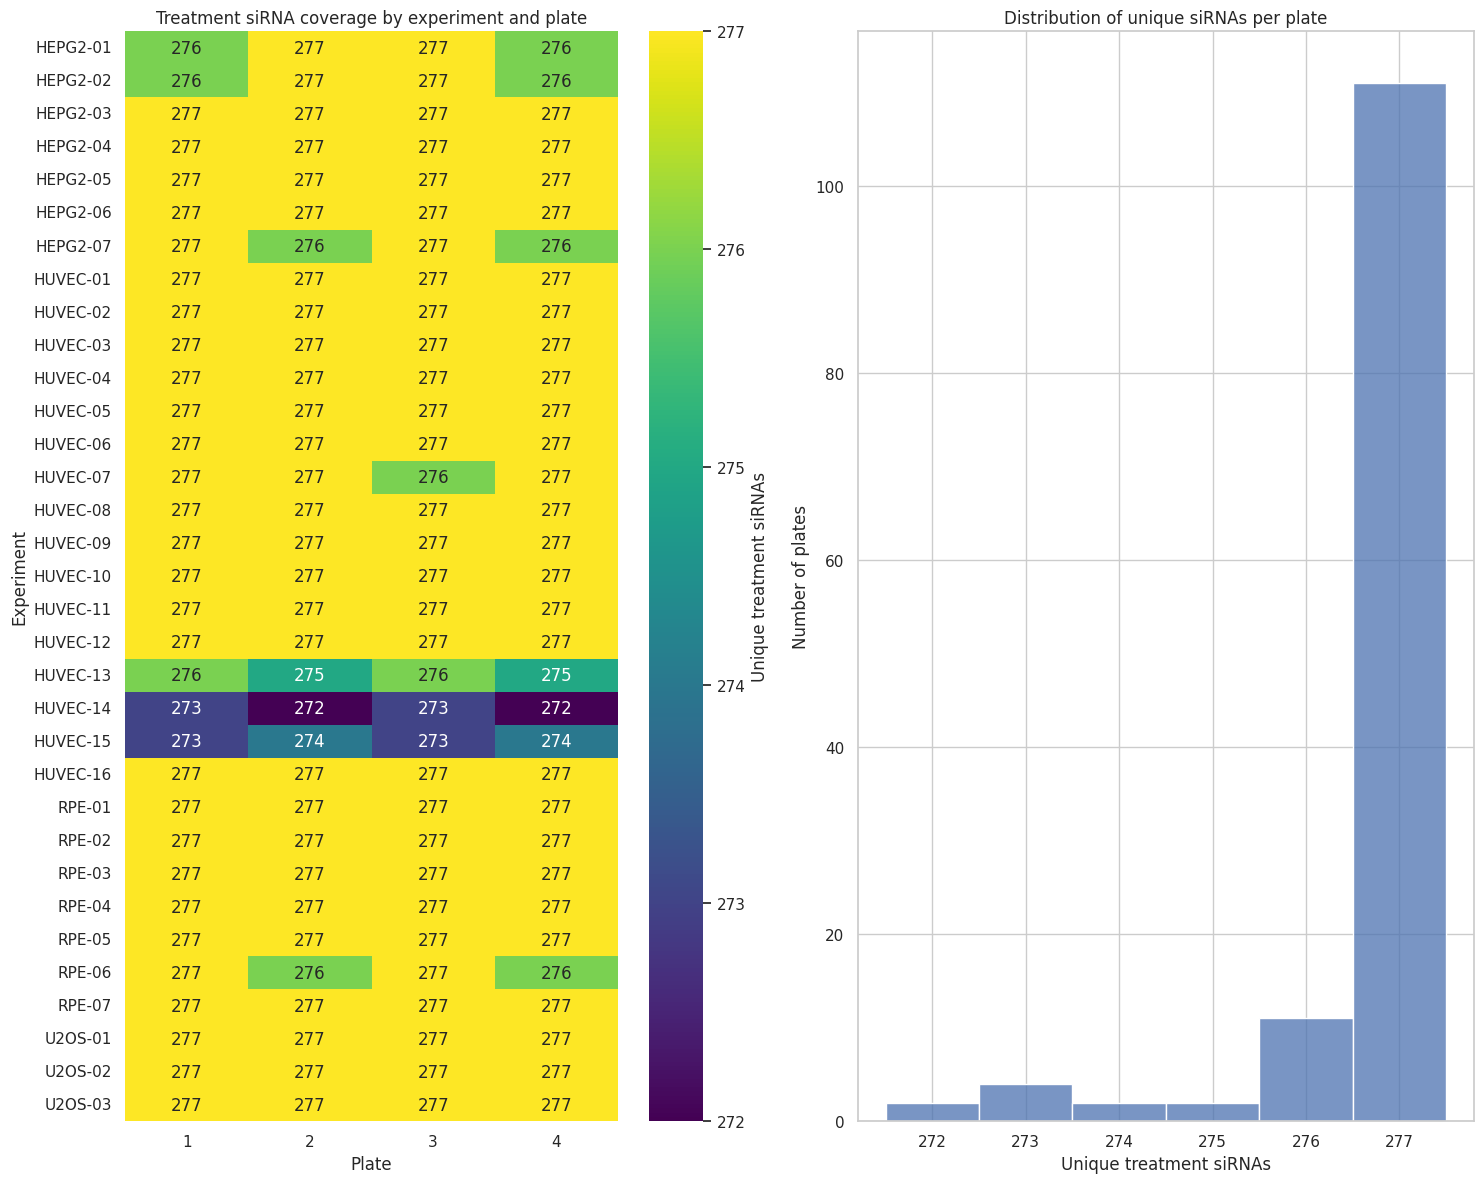

Experiments without all 1,108 treatment classes:


,cell_type,experiment,unique_sirnas,plates
0,HEPG2,HEPG2-01,1106,4
1,HEPG2,HEPG2-02,1106,4
6,HEPG2,HEPG2-07,1106,4
13,HUVEC,HUVEC-07,1107,4
19,HUVEC,HUVEC-13,1102,4
20,HUVEC,HUVEC-14,1090,4
21,HUVEC,HUVEC-15,1094,4
28,RPE,RPE-06,1106,4


In [34]:
plate_summary = (
    train.groupby(["cell_type", "experiment", "plate"])
    .agg(
        treatment_wells=("id_code", "size"),
        unique_sirnas=("sirna", "nunique"),
    )
    .reset_index()
)

plate_matrix = plate_summary.pivot(
    index="experiment",
    columns="plate",
    values="unique_sirnas",
).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 12))

sns.heatmap(
    plate_matrix,
    cmap="viridis",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Unique treatment siRNAs"},
    ax=axes[0],
)
axes[0].set_title("Treatment siRNA coverage by experiment and plate")
axes[0].set_xlabel("Plate")
axes[0].set_ylabel("Experiment")

sns.histplot(plate_summary["unique_sirnas"], discrete=True, ax=axes[1])
axes[1].set_title("Distribution of unique siRNAs per plate")
axes[1].set_xlabel("Unique treatment siRNAs")
axes[1].set_ylabel("Number of plates")

plt.tight_layout()
plt.show()

incomplete_experiments = experiment_summary.loc[
    ~experiment_summary["complete_1108"],
    ["cell_type", "experiment", "unique_sirnas", "plates"],
]
print("Experiments without all 1,108 treatment classes:")
display(incomplete_experiments)


## 6. Channel-intensity and train/test shift analysis

`pixel_stats.csv` provides an inexpensive way to inspect channel-level technical variation.
Aggregating first at the experiment level prevents large experiments from dominating the plot.
Saturation is reported because clipped pixels can remove morphological detail.

,split,channel,images,mean_intensity,median_intensity,mean_pixel_std,saturation_rate
0,test,1,44288,4.192470,2.0,4.974111,0.002416
1,test,2,44288,17.074915,11.0,13.260470,0.195900
2,test,3,44288,9.359096,7.0,5.076900,0.009754
3,test,4,44288,9.066892,6.0,6.730605,0.013728
4,test,5,44288,5.718004,3.0,4.609149,0.124436
5,test,6,44288,7.696325,6.0,3.955809,0.009190
6,train,1,81226,6.746970,2.0,7.958763,0.087780
7,train,2,81226,14.746402,10.0,12.173059,0.167705
8,train,3,81226,10.512609,8.0,5.861729,0.021508
9,train,4,81226,10.453694,6.0,7.834517,0.013136


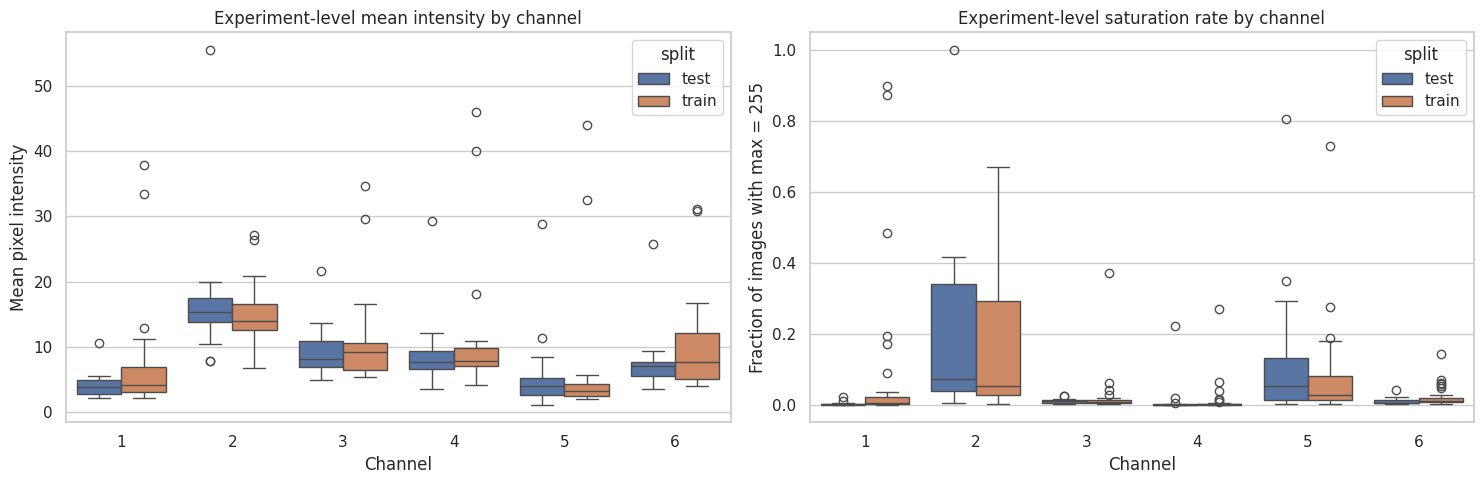

In [35]:
pixel_stats["split"] = np.where(
    pixel_stats["experiment"].isin(train_experiments),
    "train",
    "test",
)
pixel_stats["cell_type"] = (
    pixel_stats["experiment"].str.rsplit("-", n=1).str[0]
)
pixel_stats["has_saturated_pixels"] = pixel_stats["max"] >= 255

channel_summary = (
    pixel_stats.groupby(["split", "channel"])
    .agg(
        images=("id_code", "size"),
        mean_intensity=("mean", "mean"),
        median_intensity=("median", "median"),
        mean_pixel_std=("std", "mean"),
        saturation_rate=("has_saturated_pixels", "mean"),
    )
    .reset_index()
)
display(channel_summary)

experiment_channel = (
    pixel_stats.groupby(["split", "experiment", "channel"])
    .agg(
        mean_intensity=("mean", "mean"),
        saturation_rate=("has_saturated_pixels", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=experiment_channel,
    x="channel",
    y="mean_intensity",
    hue="split",
    ax=axes[0],
)
axes[0].set_title("Experiment-level mean intensity by channel")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Mean pixel intensity")

sns.boxplot(
    data=experiment_channel,
    x="channel",
    y="saturation_rate",
    hue="split",
    ax=axes[1],
)
axes[1].set_title("Experiment-level saturation rate by channel")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Fraction of images with max = 255")

plt.tight_layout()
plt.show()


## 7. Six-channel image inspection

The official RxRx1 channel order is nucleus, endoplasmic reticulum, actin, nucleoli/RNA,
mitochondria, and Golgi. Percentile scaling below is for visualization only. It must not be
mistaken for a fitted training preprocessing step.

In [36]:
CHANNEL_INFO = {
    1: ("Nucleus / DNA", "Hoechst", "Blues"),
    2: ("Endoplasmic reticulum", "ConA", "Greens"),
    3: ("Actin cytoskeleton", "Phalloidin", "Reds"),
    4: ("Nucleoli / RNA", "Syto14", "winter"),
    5: ("Mitochondria", "MitoTracker", "RdPu"),
    6: ("Golgi / glycoproteins", "WGA", "YlOrBr"),
}

RXRX1_COLORS = np.array(
    [
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 1],
        [1, 0, 1],
        [1, 1, 0],
    ],
    dtype=np.float32,
)

def get_image_path(row, channel, split="train"):
    return (
        DATASET_PATH
        / split
        / str(row["experiment"])
        / f"Plate{int(row['plate'])}"
        / f"{row['well']}_s{int(row['site'])}_w{int(channel)}.png"
    )

def load_site(experiment, plate, well, site=1, split="train"):
    channels = []
    for channel in range(1, 7):
        path = (
            DATASET_PATH
            / split
            / str(experiment)
            / f"Plate{int(plate)}"
            / f"{well}_s{int(site)}_w{channel}.png"
        )
        if not path.exists():
            raise FileNotFoundError(f"Image not found: {path}")
        channels.append(np.asarray(Image.open(path), dtype=np.float32))
    return np.stack(channels, axis=-1)

def percentile_scale(image, low=1, high=99):
    scaled = np.zeros_like(image, dtype=np.float32)
    for channel_index in range(image.shape[-1]):
        values = image[..., channel_index]
        lower = np.percentile(values, low)
        upper = np.percentile(values, high)
        if upper <= lower:
            upper = lower + 1e-6
        scaled[..., channel_index] = np.clip(
            (values - lower) / (upper - lower), 0, 1
        )
    return scaled

def six_channel_to_rgb(image):
    rgb = image @ RXRX1_COLORS
    return np.clip(rgb / (1.0 + rgb), 0, 1)

def plot_six_channels(experiment, plate, well, site=1, split="train"):
    image = load_site(experiment, plate, well, site, split)
    image_display = percentile_scale(image)

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for channel, ax in enumerate(axes.flat, start=1):
        structure, stain, cmap = CHANNEL_INFO[channel]
        ax.imshow(image_display[..., channel - 1], cmap=cmap)
        ax.set_title(f"w{channel}: {structure}\n{stain}")
        ax.axis("off")

    fig.suptitle(
        f"{experiment} | Plate {plate} | {well} | site {site}",
        fontsize=15,
    )
    plt.tight_layout()
    plt.show()

def plot_site_comparison(experiment, plate, well, split="train"):
    site1 = load_site(experiment, plate, well, site=1, split=split)
    site2 = load_site(experiment, plate, well, site=2, split=split)
    site1_display = percentile_scale(site1)
    site2_display = percentile_scale(site2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(six_channel_to_rgb(site1_display))
    axes[0].set_title("Site 1 composite")
    axes[1].imshow(six_channel_to_rgb(site2_display))
    axes[1].set_title("Site 2 composite")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{experiment} | Plate {plate} | {well}")
    plt.tight_layout()
    plt.show()


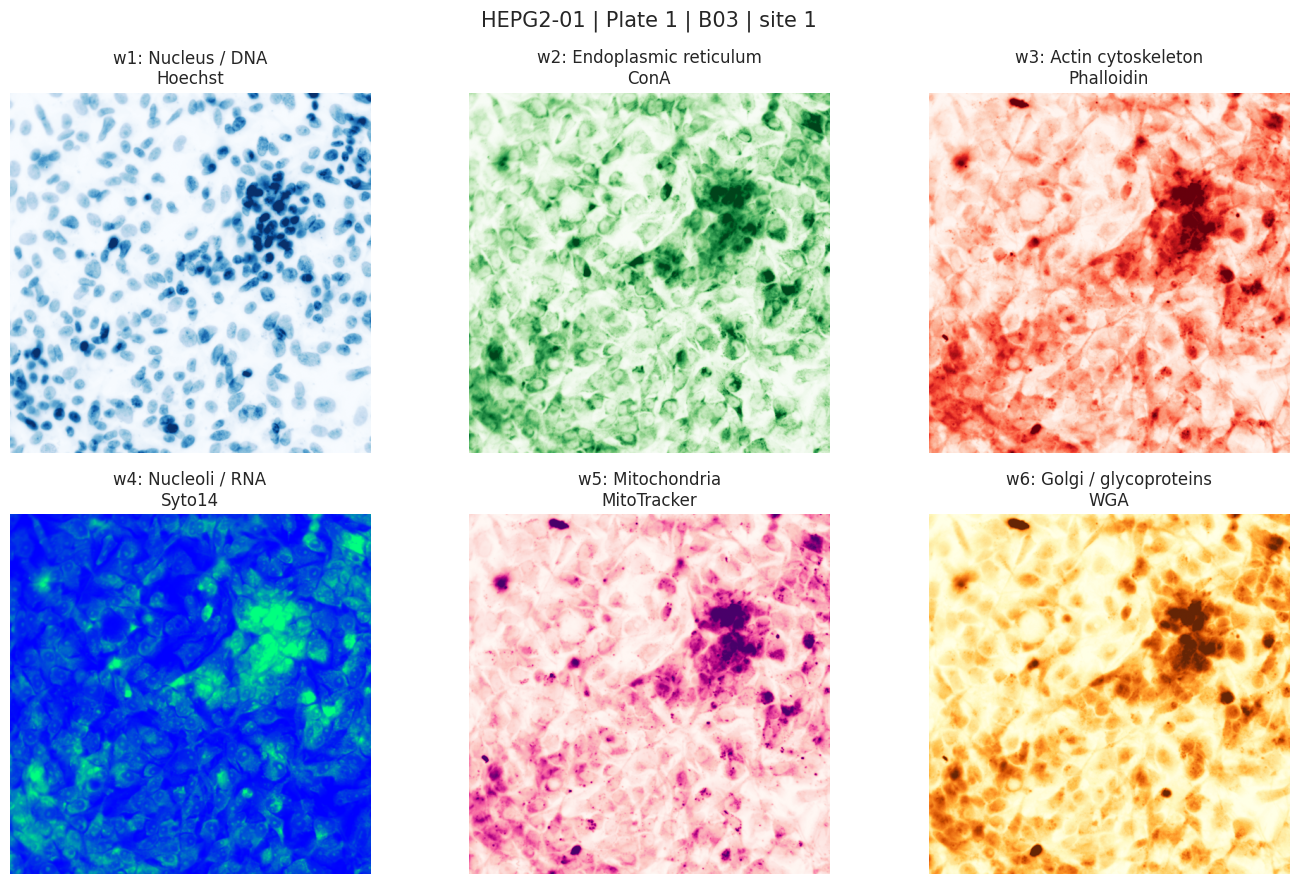

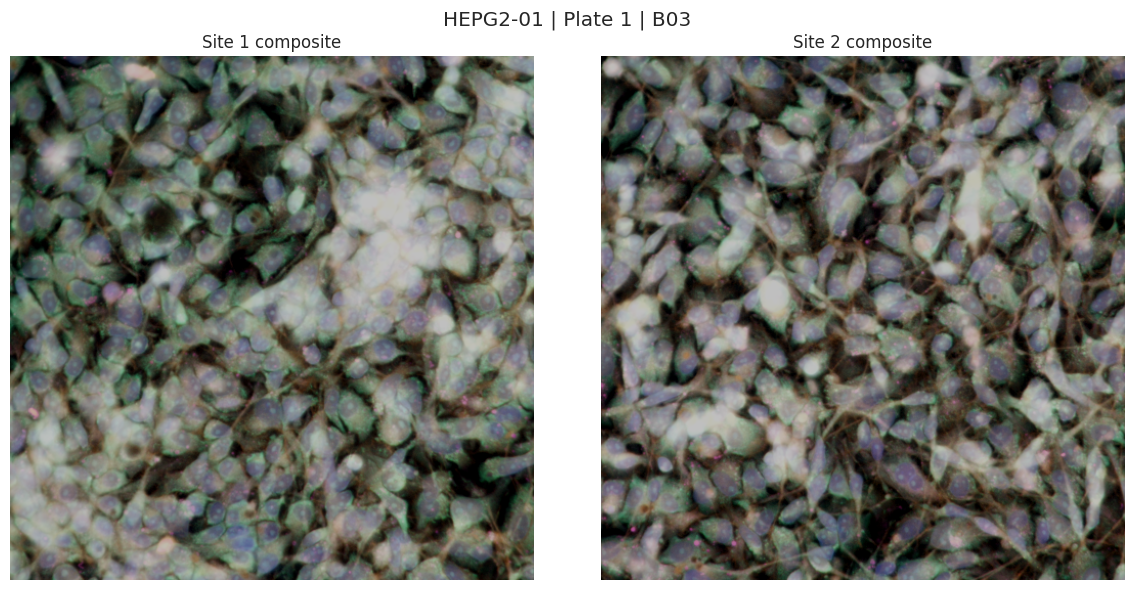

In [37]:
sample_row = train.sort_values(["experiment", "plate", "well"]).iloc[0]

plot_six_channels(
    experiment=sample_row["experiment"],
    plate=sample_row["plate"],
    well=sample_row["well"],
    site=1,
)

plot_site_comparison(
    experiment=sample_row["experiment"],
    plate=sample_row["plate"],
    well=sample_row["well"],
)


## 8. Representative plate and batch effects

Comparisons are matched on biological condition:

- Plate effect: the same control siRNA in the same experiment but on different plates.
- Batch effect: the same treatment siRNA in the same cell type but in different experiments.

The intensity reference uses untreated negative controls only. Positive controls have real
perturbation phenotypes and should not be treated as a neutral plate baseline. This visual
normalization is exploratory; any normalization used for model evaluation must be fitted only
on the training partition.

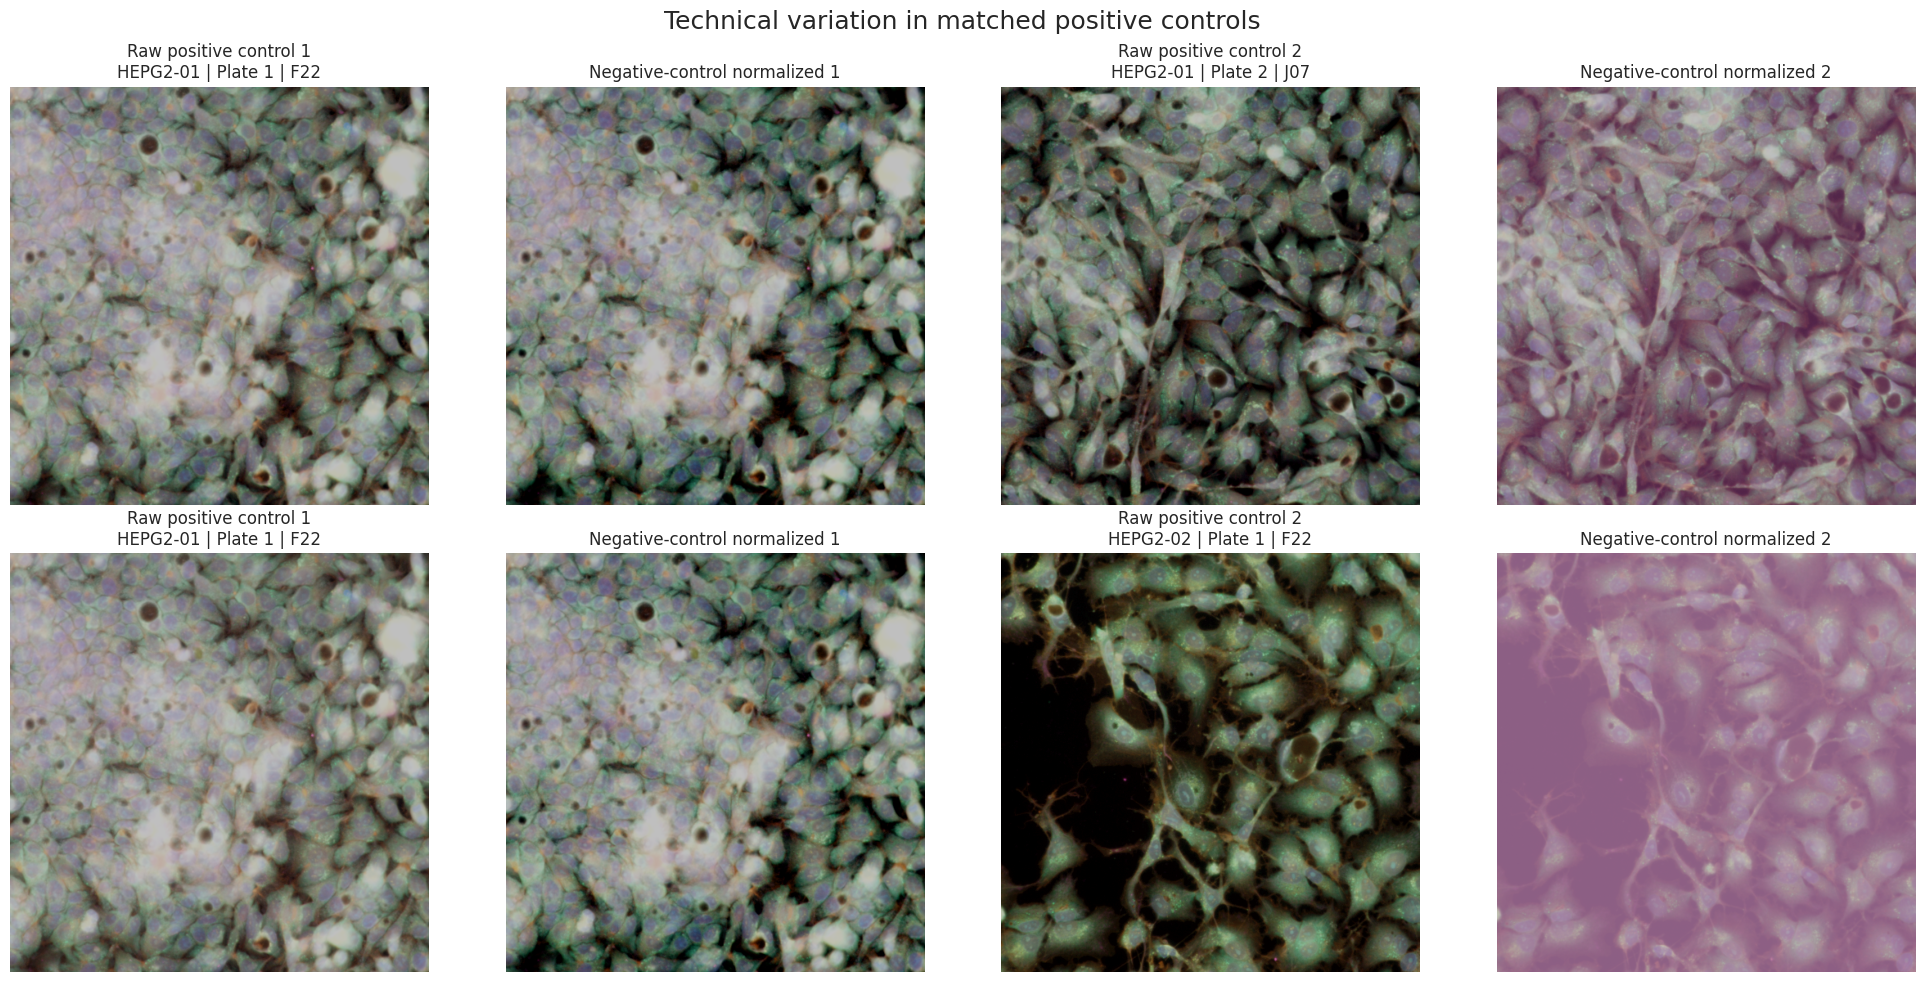

{'plate_effect': {'sirna': 'sirna_1011',
  'image1': {'experiment': 'HEPG2-01', 'plate': 1, 'well': 'F22', 'site': 1},
  'image2': {'experiment': 'HEPG2-01', 'plate': 2, 'well': 'J07', 'site': 1}},
 'experiment_effect': {'sirna': 'sirna_1011',
  'image1': {'experiment': 'HEPG2-01', 'plate': 1, 'well': 'F22', 'site': 1},
  'image2': {'experiment': 'HEPG2-02', 'plate': 1, 'well': 'F22', 'site': 1}}}

In [38]:
_negative_control_cache = {}

def shared_percentile_scale(image1, image2, low=1, high=99):
    output1 = np.zeros_like(image1, dtype=np.float32)
    output2 = np.zeros_like(image2, dtype=np.float32)

    for channel_index in range(6):
        combined = np.concatenate(
            [image1[..., channel_index].ravel(), image2[..., channel_index].ravel()]
        )
        lower = np.percentile(combined, low)
        upper = np.percentile(combined, high)
        if upper <= lower:
            upper = lower + 1e-6
        output1[..., channel_index] = np.clip(
            (image1[..., channel_index] - lower) / (upper - lower), 0, 1
        )
        output2[..., channel_index] = np.clip(
            (image2[..., channel_index] - lower) / (upper - lower), 0, 1
        )

    return output1, output2

def negative_control_reference(experiment, plate, sample_stride=32):
    cache_key = (str(experiment), int(plate), int(sample_stride))
    if cache_key in _negative_control_cache:
        return _negative_control_cache[cache_key]

    negative_controls = controls.loc[
        (controls["experiment"] == experiment)
        & (controls["plate"] == int(plate))
        & (controls["well_type"] == "negative_control")
    ]

    if negative_controls.empty:
        raise ValueError(
            f"No untreated negative control was found for {experiment} Plate{plate}."
        )

    sampled_pixels = [[] for _ in range(6)]
    for row in negative_controls.itertuples(index=False):
        for site in (1, 2):
            image = load_site(
                row.experiment,
                row.plate,
                row.well,
                site=site,
            )
            for channel_index in range(6):
                sampled_pixels[channel_index].append(
                    image[..., channel_index].ravel()[::sample_stride]
                )

    medians = np.zeros(6, dtype=np.float32)
    scales = np.zeros(6, dtype=np.float32)
    for channel_index in range(6):
        values = np.concatenate(sampled_pixels[channel_index])
        medians[channel_index] = np.median(values)
        q25, q75 = np.percentile(values, [25, 75])
        scales[channel_index] = max(q75 - q25, 1e-6)

    _negative_control_cache[cache_key] = (medians, scales)
    return medians, scales

def normalize_with_negative_control(image, experiment, plate):
    median, scale = negative_control_reference(experiment, plate)
    return (
        image - median.reshape(1, 1, 6)
    ) / scale.reshape(1, 1, 6)

def find_plate_effect_pair(site=1):
    positive_controls = controls.loc[
        controls["well_type"] == "positive_control"
    ].copy()

    candidates = (
        positive_controls.groupby(["experiment", "sirna"])["plate"]
        .nunique()
        .loc[lambda values: values >= 2]
        .sort_index()
    )
    if candidates.empty:
        raise ValueError("No matched positive-control plate pair was found.")

    experiment, sirna = candidates.index[0]
    pair = (
        positive_controls.loc[
            (positive_controls["experiment"] == experiment)
            & (positive_controls["sirna"] == sirna)
        ]
        .sort_values(["plate", "well"])
        .drop_duplicates("plate")
        .iloc[:2]
    )

    info = [
        {
            "experiment": row.experiment,
            "plate": int(row.plate),
            "well": row.well,
            "site": site,
        }
        for row in pair.itertuples(index=False)
    ]
    return info[0], info[1], sirna

def find_experiment_effect_pair(site=1):
    positive_controls = controls.loc[
        controls["well_type"] == "positive_control"
    ].copy()

    candidates = (
        positive_controls
        .groupby(["cell_type", "sirna"])["experiment"]
        .nunique()
        .loc[lambda values: values >= 2]
        .sort_index()
    )

    if candidates.empty:
        raise ValueError(
            "No matched positive-control experiment pair was found."
        )

    cell_type, sirna = candidates.index[0]

    pair = (
        positive_controls.loc[
            (positive_controls["cell_type"] == cell_type)
            & (positive_controls["sirna"] == sirna)
        ]
        .sort_values(["experiment", "plate", "well"])
        .drop_duplicates("experiment")
        .iloc[:2]
    )

    info = [
        {
            "experiment": row.experiment,
            "plate": int(row.plate),
            "well": row.well,
            "site": site,
        }
        for row in pair.itertuples(index=False)
    ]

    return info[0], info[1], sirna

def prepare_technical_pair(info1, info2):
    raw1 = load_site(**info1)
    raw2 = load_site(**info2)
    raw1_display, raw2_display = shared_percentile_scale(raw1, raw2)

    normalized1 = normalize_with_negative_control(
        raw1, info1["experiment"], info1["plate"]
    )
    normalized2 = normalize_with_negative_control(
        raw2, info2["experiment"], info2["plate"]
    )
    normalized1_display, normalized2_display = shared_percentile_scale(
        normalized1, normalized2
    )

    return (
        six_channel_to_rgb(raw1_display),
        six_channel_to_rgb(normalized1_display),
        six_channel_to_rgb(raw2_display),
        six_channel_to_rgb(normalized2_display),
    )

def plot_technical_effects(site=1):
    plate1, plate2, plate_sirna = find_plate_effect_pair(site=site)

    experiment1, experiment2, experiment_sirna = (
        find_experiment_effect_pair(site=site)
    )

    rows = [
        ("Plate effect", plate1, plate2, plate_sirna),
        (
            "Experiment effect",
            experiment1,
            experiment2,
            experiment_sirna,
        ),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for row_index, (label, info1, info2, sirna) in enumerate(rows):
        images = prepare_technical_pair(info1, info2)

        titles = [
            (
                f"Raw positive control 1\n"
                f"{info1['experiment']} | "
                f"Plate {info1['plate']} | {info1['well']}"
            ),
            "Negative-control normalized 1",
            (
                f"Raw positive control 2\n"
                f"{info2['experiment']} | "
                f"Plate {info2['plate']} | {info2['well']}"
            ),
            "Negative-control normalized 2",
        ]

        for column_index, (image, title) in enumerate(
            zip(images, titles)
        ):
            axes[row_index, column_index].imshow(image)
            axes[row_index, column_index].set_title(title)
            axes[row_index, column_index].axis("off")

        axes[row_index, 0].set_ylabel(
            f"{label}\nsame positive-control siRNA: {sirna}",
            fontsize=12,
            fontweight="bold",
        )

    fig.suptitle(
        "Technical variation in matched positive controls",
        fontsize=18,
    )
    plt.tight_layout()
    plt.show()

    return {
        "plate_effect": {
            "sirna": plate_sirna,
            "image1": plate1,
            "image2": plate2,
        },
        "experiment_effect": {
            "sirna": experiment_sirna,
            "image1": experiment1,
            "image2": experiment2,
        },
    }

technical_examples = plot_technical_effects(site=1)
display(technical_examples)


## 9. Proxy dataset design

The four logical datasets vary class count and site count while maintaining explicit nesting:

| Dataset | Experiments | Treatment classes | Sites | Purpose |
|---|---:|---:|---:|---|
| D1 | 9 | 400 | 1 | Main development and hyperparameter search |
| D2 | 4, nested in D1 | Same 400 | 2 | Site-fusion experiments |
| D3 | 4 held-out complete experiments | 1,108 | 1 | Full-class confirmation |
| D4 | 2, nested in D3 | 1,108 | 2 | Full-class site confirmation |

A complete held-out experiment is reserved for D3 before D1 is sampled. This prevents the
random D1 selection from consuming the only eligible D3 experiment for a cell type.

In [39]:
# ============================================================
# Frozen experiment split and proxy siRNA selection
# ============================================================

sirna_rng = np.random.default_rng(SEED + 1)

# ============================================================
# 1. Experiment metadata summary
# ============================================================

experiment_info = (
    train.groupby(["cell_type", "experiment"])
    .agg(
        rows=("id_code", "size"),
        unique_sirnas=("sirna", "nunique"),
        plates=("plate", "nunique"),
    )
    .reset_index()
)

experiment_info["complete_1108"] = (
    experiment_info["unique_sirnas"]
    == N_FULL_SIRNA
)

display(
    experiment_info.sort_values(
        ["cell_type", "experiment"]
    )
)

# ============================================================
# 2. Frozen experiment splits
#
# These splits must remain unchanged across:
# - HPO trials
# - model architectures
# - training seeds
# - image resolutions
# ============================================================

d1_train_experiments = sorted([
    "HEPG2-05",
    "HEPG2-07",
    "HUVEC-02",
    "HUVEC-04",
    "HUVEC-11",
    "HUVEC-12",
    "RPE-04",
    "RPE-06",
    "U2OS-01",
])

d1_val_experiments = sorted([
    "HEPG2-04",
    "HUVEC-03",
    "RPE-01",
    "U2OS-03",
])

# D2 uses both sites and is nested in D1.
d2_train_experiments = sorted([
    "HEPG2-05",
    "HUVEC-02",
    "RPE-04",
    "U2OS-01",
])

d2_val_experiments = (
    d1_val_experiments.copy()
)

# D3 uses all 1,108 classes and Site 1.
d3_train_experiments = sorted([
    "HEPG2-03",
    "HUVEC-01",
    "RPE-05",
    "U2OS-02",
])

d3_val_experiments = (
    d1_val_experiments.copy()
)

# D4 uses all 1,108 classes and both sites.
# HUVEC-06 is excluded because Plate1/B18/Site2 is missing.
d4_train_experiments = sorted([
    "HEPG2-03",
    "HUVEC-01",
])

d4_val_experiments = sorted([
    "HEPG2-04",
    "HUVEC-03",
])

split_info = {
    "D1_train": d1_train_experiments,
    "D1_val": d1_val_experiments,
    "D2_train": d2_train_experiments,
    "D2_val": d2_val_experiments,
    "D3_train": d3_train_experiments,
    "D3_val": d3_val_experiments,
    "D4_train": d4_train_experiments,
    "D4_val": d4_val_experiments,
}

# ============================================================
# 3. Validate experiment names
# ============================================================

all_available_experiments = set(
    experiment_info["experiment"]
)

for split_name, experiments in split_info.items():
    unknown_experiments = (
        set(experiments)
        - all_available_experiments
    )

    assert not unknown_experiments, (
        f"{split_name} contains unknown experiments: "
        f"{sorted(unknown_experiments)}"
    )

# ============================================================
# 4. Validate train/validation separation
# ============================================================

assert set(d1_train_experiments).isdisjoint(
    d1_val_experiments
)

assert set(d3_train_experiments).isdisjoint(
    d3_val_experiments
)

assert set(d2_train_experiments).issubset(
    d1_train_experiments
)

assert set(d2_val_experiments).issubset(
    d1_val_experiments
)

assert set(d4_train_experiments).issubset(
    d3_train_experiments
)

assert set(d4_val_experiments).issubset(
    d3_val_experiments
)

assert "HUVEC-06" not in d3_train_experiments
assert "HUVEC-06" not in d4_train_experiments

# ============================================================
# 5. Validate cell-type composition
# ============================================================

def experiment_cell_type_counts(experiments):
    return (
        pd.Series(experiments)
        .str.rsplit("-", n=1)
        .str[0]
        .value_counts()
        .sort_index()
        .to_dict()
    )

assert experiment_cell_type_counts(
    d1_train_experiments
) == {
    "HEPG2": 2,
    "HUVEC": 4,
    "RPE": 2,
    "U2OS": 1,
}

assert experiment_cell_type_counts(
    d1_val_experiments
) == {
    "HEPG2": 1,
    "HUVEC": 1,
    "RPE": 1,
    "U2OS": 1,
}

assert experiment_cell_type_counts(
    d2_train_experiments
) == {
    "HEPG2": 1,
    "HUVEC": 1,
    "RPE": 1,
    "U2OS": 1,
}

assert experiment_cell_type_counts(
    d2_val_experiments
) == {
    "HEPG2": 1,
    "HUVEC": 1,
    "RPE": 1,
    "U2OS": 1,
}

assert experiment_cell_type_counts(
    d3_train_experiments
) == {
    "HEPG2": 1,
    "HUVEC": 1,
    "RPE": 1,
    "U2OS": 1,
}

assert experiment_cell_type_counts(
    d3_val_experiments
) == {
    "HEPG2": 1,
    "HUVEC": 1,
    "RPE": 1,
    "U2OS": 1,
}

assert experiment_cell_type_counts(
    d4_train_experiments
) == {
    "HEPG2": 1,
    "HUVEC": 1,
}

assert experiment_cell_type_counts(
    d4_val_experiments
) == {
    "HEPG2": 1,
    "HUVEC": 1,
}

# ============================================================
# 6. Validate complete 1,108-class experiments
# ============================================================

full_class_experiments = sorted(
    set(
        d3_train_experiments
        + d3_val_experiments
        + d4_train_experiments
        + d4_val_experiments
    )
)

full_class_check = (
    experiment_info.loc[
        experiment_info["experiment"].isin(
            full_class_experiments
        ),
        [
            "cell_type",
            "experiment",
            "unique_sirnas",
            "plates",
            "complete_1108",
        ],
    ]
    .sort_values(["cell_type", "experiment"])
    .reset_index(drop=True)
)

display(full_class_check)

assert set(full_class_check["experiment"]) == set(
    full_class_experiments
)

assert full_class_check["unique_sirnas"].eq(
    N_FULL_SIRNA
).all()

assert full_class_check["complete_1108"].all()
assert full_class_check["plates"].eq(4).all()

# ============================================================
# 7. Select 400 siRNAs shared by all D1 training experiments
# ============================================================

common_sirnas = set(
    train.loc[
        train["experiment"]
        == d1_train_experiments[0],
        "sirna",
    ]
)

for experiment in d1_train_experiments[1:]:
    experiment_sirnas = set(
        train.loc[
            train["experiment"] == experiment,
            "sirna",
        ]
    )

    common_sirnas &= experiment_sirnas

common_sirnas = sorted(common_sirnas)

if len(common_sirnas) < N_PROXY_SIRNA:
    raise ValueError(
        f"Only {len(common_sirnas)} siRNAs are "
        f"shared by all D1 training experiments; "
        f"{N_PROXY_SIRNA} are required."
    )

sirna_rng = np.random.default_rng(SEED + 1)

proxy_sirnas = sorted(
    sirna_rng.choice(
        np.array(common_sirnas),
        size=N_PROXY_SIRNA,
        replace=False,
    ).tolist()
)

assert len(proxy_sirnas) == N_PROXY_SIRNA
assert len(set(proxy_sirnas)) == N_PROXY_SIRNA
assert set(proxy_sirnas).issubset(
    common_sirnas
)

# ============================================================
# 8. Validate proxy labels in D1 validation experiments
# ============================================================

for experiment in d1_val_experiments:
    available_sirnas = set(
        train.loc[
            train["experiment"] == experiment,
            "sirna",
        ]
    )

    missing_proxy_sirnas = (
        set(proxy_sirnas)
        - available_sirnas
    )

    assert not missing_proxy_sirnas, (
        f"{experiment} is missing "
        f"{len(missing_proxy_sirnas)} proxy siRNAs."
    )

# ============================================================
# 9. Manifest builder functions
# ============================================================

def expand_sites(frame, sites):
    parts = []

    for site in sites:
        part = frame.copy()
        part["site"] = int(site)
        parts.append(part)

    return pd.concat(
        parts,
        ignore_index=True,
    )

def build_treatment_manifest(
    frame,
    experiments,
    sites,
    sirnas=None,
):
    output = frame.loc[
        frame["experiment"].isin(experiments)
    ].copy()

    if sirnas is not None:
        output = output.loc[
            output["sirna"].isin(sirnas)
        ].copy()

    output = expand_sites(
        output,
        sites,
    )

    return (
        output.sort_values(
            [
                "experiment",
                "plate",
                "well",
                "site",
            ]
        )
        .reset_index(drop=True)
    )

def build_control_manifest(
    frame,
    experiments,
    sites,
):
    output = frame.loc[
        frame["experiment"].isin(experiments)
    ].copy()

    output = expand_sites(
        output,
        sites,
    )

    return (
        output.sort_values(
            [
                "experiment",
                "plate",
                "well",
                "site",
            ]
        )
        .reset_index(drop=True)
    )

# ============================================================
# 10. Build D1-D4 training and validation manifests
# ============================================================

datasets = {
    "D1": {
        "train_treatment": build_treatment_manifest(
            train,
            d1_train_experiments,
            sites=(1,),
            sirnas=proxy_sirnas,
        ),
        "train_control": build_control_manifest(
            controls,
            d1_train_experiments,
            sites=(1,),
        ),
        "val_treatment": build_treatment_manifest(
            train,
            d1_val_experiments,
            sites=(1,),
            sirnas=proxy_sirnas,
        ),
        "val_control": build_control_manifest(
            controls,
            d1_val_experiments,
            sites=(1,),
        ),
    },

    "D2": {
        "train_treatment": build_treatment_manifest(
            train,
            d2_train_experiments,
            sites=(1, 2),
            sirnas=proxy_sirnas,
        ),
        "train_control": build_control_manifest(
            controls,
            d2_train_experiments,
            sites=(1, 2),
        ),
        "val_treatment": build_treatment_manifest(
            train,
            d2_val_experiments,
            sites=(1, 2),
            sirnas=proxy_sirnas,
        ),
        "val_control": build_control_manifest(
            controls,
            d2_val_experiments,
            sites=(1, 2),
        ),
    },

    "D3": {
        "train_treatment": build_treatment_manifest(
            train,
            d3_train_experiments,
            sites=(1,),
            sirnas=None,
        ),
        "train_control": build_control_manifest(
            controls,
            d3_train_experiments,
            sites=(1,),
        ),
        "val_treatment": build_treatment_manifest(
            train,
            d3_val_experiments,
            sites=(1,),
            sirnas=None,
        ),
        "val_control": build_control_manifest(
            controls,
            d3_val_experiments,
            sites=(1,),
        ),
    },

    "D4": {
        "train_treatment": build_treatment_manifest(
            train,
            d4_train_experiments,
            sites=(1, 2),
            sirnas=None,
        ),
        "train_control": build_control_manifest(
            controls,
            d4_train_experiments,
            sites=(1, 2),
        ),
        "val_treatment": build_treatment_manifest(
            train,
            d4_val_experiments,
            sites=(1, 2),
            sirnas=None,
        ),
        "val_control": build_control_manifest(
            controls,
            d4_val_experiments,
            sites=(1, 2),
        ),
    },
}

# ============================================================
# 11. Dataset-level sanity checks
# ============================================================

EXPECTED_SPLITS = {
    ("D1", "train"): {
        "experiments": 9,
        "cell_types": 4,
        "sirnas": 400,
        "sites": 1,
        "samples_per_class": 9,
    },
    ("D1", "val"): {
        "experiments": 4,
        "cell_types": 4,
        "sirnas": 400,
        "sites": 1,
        "samples_per_class": 4,
    },
    ("D2", "train"): {
        "experiments": 4,
        "cell_types": 4,
        "sirnas": 400,
        "sites": 2,
        "samples_per_class": 8,
    },
    ("D2", "val"): {
        "experiments": 4,
        "cell_types": 4,
        "sirnas": 400,
        "sites": 2,
        "samples_per_class": 8,
    },
    ("D3", "train"): {
        "experiments": 4,
        "cell_types": 4,
        "sirnas": 1108,
        "sites": 1,
        "samples_per_class": 4,
    },
    ("D3", "val"): {
        "experiments": 4,
        "cell_types": 4,
        "sirnas": 1108,
        "sites": 1,
        "samples_per_class": 4,
    },
    ("D4", "train"): {
        "experiments": 2,
        "cell_types": 2,
        "sirnas": 1108,
        "sites": 2,
        "samples_per_class": 4,
    },
    ("D4", "val"): {
        "experiments": 2,
        "cell_types": 2,
        "sirnas": 1108,
        "sites": 2,
        "samples_per_class": 4,
    },
}

summary_rows = []

for (
    dataset_name,
    role,
), expected in EXPECTED_SPLITS.items():

    treatment = datasets[dataset_name][
        f"{role}_treatment"
    ]

    control = datasets[dataset_name][
        f"{role}_control"
    ]

    class_counts = (
        treatment["sirna"]
        .value_counts()
    )

    assert treatment["experiment"].nunique() == (
        expected["experiments"]
    )

    assert treatment["cell_type"].nunique() == (
        expected["cell_types"]
    )

    assert treatment["sirna"].nunique() == (
        expected["sirnas"]
    )

    assert treatment["site"].nunique() == (
        expected["sites"]
    )

    assert class_counts.min() == (
        expected["samples_per_class"]
    )

    assert class_counts.max() == (
        expected["samples_per_class"]
    )

    assert not treatment.duplicated(
        [
            "experiment",
            "plate",
            "well",
            "site",
        ]
    ).any()

    assert not control.duplicated(
        [
            "experiment",
            "plate",
            "well",
            "site",
        ]
    ).any()

    summary_rows.append({
        "dataset": dataset_name,
        "role": role,
        "experiments": (
            treatment["experiment"].nunique()
        ),
        "cell_types": (
            treatment["cell_type"].nunique()
        ),
        "sirnas": (
            treatment["sirna"].nunique()
        ),
        "sites": (
            treatment["site"].nunique()
        ),
        "treatment_site_samples": len(treatment),
        "control_site_samples": len(control),
        "total_png_references": (
            len(treatment) + len(control)
        ) * 6,
        "min_samples_per_class": int(
            class_counts.min()
        ),
        "max_samples_per_class": int(
            class_counts.max()
        ),
    })

dataset_summary = pd.DataFrame(
    summary_rows
)

display(dataset_summary)

# ============================================================
# 12. Validate D2/D1 and D4/D3 nesting
# ============================================================

KEY_COLUMNS = [
    "experiment",
    "plate",
    "well",
    "site",
]

def combined_key_set(
    dataset_name,
    role,
    site=None,
):
    frame = pd.concat(
        [
            datasets[dataset_name][
                f"{role}_treatment"
            ],
            datasets[dataset_name][
                f"{role}_control"
            ],
        ],
        ignore_index=True,
    )

    if site is not None:
        frame = frame.loc[
            frame["site"] == site
        ]

    return set(
        frame[KEY_COLUMNS]
        .itertuples(
            index=False,
            name=None,
        )
    )

assert combined_key_set(
    "D2",
    "train",
    site=1,
).issubset(
    combined_key_set(
        "D1",
        "train",
    )
)

assert combined_key_set(
    "D2",
    "val",
    site=1,
).issubset(
    combined_key_set(
        "D1",
        "val",
    )
)

assert combined_key_set(
    "D4",
    "train",
    site=1,
).issubset(
    combined_key_set(
        "D3",
        "train",
    )
)

assert combined_key_set(
    "D4",
    "val",
    site=1,
).issubset(
    combined_key_set(
        "D3",
        "val",
    )
)

print("PASS: all dataset nesting checks succeeded.")

# ============================================================
# 13. Create a design fingerprint and output directories
# ============================================================

design_payload = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "experiment_splits": split_info,
    "proxy_sirnas": proxy_sirnas,
}

design_fingerprint = hashlib.sha256(
    json.dumps(
        design_payload,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:10]

PACKAGE_ROOT = Path(
    f"/kaggle/working/"
    f"rxrx1_proxy_{IMAGE_SIZE}_"
    f"{design_fingerprint}"
)

IMAGES_ROOT = PACKAGE_ROOT / "images"
MANIFESTS_ROOT = PACKAGE_ROOT / "manifests"
REPORTS_ROOT = PACKAGE_ROOT / "reports"

for directory in (
    MANIFESTS_ROOT,
    REPORTS_ROOT,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

# ============================================================
# 14. Save 16 train/validation manifests
# ============================================================

saved_manifests = {}

for dataset_name, parts in datasets.items():
    for split_name, source_manifest in parts.items():
        manifest = (
            source_manifest.copy()
            .reset_index(drop=True)
        )

        manifest["site"] = (
            manifest["site"].astype(int)
        )

        manifest["plate"] = (
            manifest["plate"].astype(int)
        )

        manifest["image_dir"] = manifest.apply(
            lambda row: (
                Path("images")
                / str(row["experiment"])
                / f"Plate{int(row['plate'])}"
            ).as_posix(),
            axis=1,
        )

        manifest["image_pattern"] = (
            manifest.apply(
                lambda row: (
                    f"{row['well']}_"
                    f"s{int(row['site'])}_"
                    f"w{{channel}}.png"
                ),
                axis=1,
            )
        )

        output_path = (
            MANIFESTS_ROOT
            / (
                f"{dataset_name.lower()}_"
                f"{split_name}.csv"
            )
        )

        manifest.to_csv(
            output_path,
            index=False,
        )

        saved_manifests[
            (dataset_name, split_name)
        ] = manifest

# ============================================================
# 15. Save experiment and label design files
# ============================================================

pd.DataFrame({
    split_name: pd.Series(experiments)
    for split_name, experiments
    in split_info.items()
}).to_csv(
    MANIFESTS_ROOT
    / "experiment_split.csv",
    index=False,
)

pd.DataFrame({
    "sirna": proxy_sirnas
}).to_csv(
    MANIFESTS_ROOT
    / "proxy_400_sirnas.csv",
    index=False,
)

dataset_summary.to_csv(
    REPORTS_ROOT
    / "logical_dataset_summary.csv",
    index=False,
)

(
    REPORTS_ROOT
    / "design.json"
).write_text(
    json.dumps(
        design_payload,
        indent=2,
    ),
    encoding="utf-8",
)

# ============================================================
# 16. Final manifest checks
# ============================================================

expected_manifest_files = {
    f"d{dataset_number}_{role}_{split}.csv"
    for dataset_number in range(1, 5)
    for role in ("train", "val")
    for split in ("treatment", "control")
}

actual_manifest_files = {
    path.name
    for path in MANIFESTS_ROOT.glob(
        "d*_*.csv"
    )
}

assert actual_manifest_files == (
    expected_manifest_files
), (
    "Unexpected manifest files.\n"
    f"Expected: {sorted(expected_manifest_files)}\n"
    f"Actual: {sorted(actual_manifest_files)}"
)

assert len(saved_manifests) == 16

split_table = pd.concat(
    {
        split_name: pd.Series(experiments)
        for split_name, experiments
        in split_info.items()
    },
    axis=1,
)

display(split_table)

print(
    "Shared siRNAs available for D1:",
    len(common_sirnas),
)

print(
    "Selected proxy siRNAs:",
    len(proxy_sirnas),
)

print(
    "Design fingerprint:",
    design_fingerprint,
)

print(
    "Package root:",
    PACKAGE_ROOT,
)

print(
    "Saved 16 train/validation manifests."
)


,cell_type,experiment,rows,unique_sirnas,plates,complete_1108
0,HEPG2,HEPG2-01,1106,1106,4,False
1,HEPG2,HEPG2-02,1106,1106,4,False
2,HEPG2,HEPG2-03,1108,1108,4,True
3,HEPG2,HEPG2-04,1108,1108,4,True
4,HEPG2,HEPG2-05,1108,1108,4,True
5,HEPG2,HEPG2-06,1108,1108,4,True
6,HEPG2,HEPG2-07,1106,1106,4,False
7,HUVEC,HUVEC-01,1108,1108,4,True
8,HUVEC,HUVEC-02,1108,1108,4,True
9,HUVEC,HUVEC-03,1108,1108,4,True


,cell_type,experiment,unique_sirnas,plates,complete_1108
0,HEPG2,HEPG2-03,1108,4,True
1,HEPG2,HEPG2-04,1108,4,True
2,HUVEC,HUVEC-01,1108,4,True
3,HUVEC,HUVEC-03,1108,4,True
4,RPE,RPE-01,1108,4,True
5,RPE,RPE-05,1108,4,True
6,U2OS,U2OS-02,1108,4,True
7,U2OS,U2OS-03,1108,4,True


,dataset,role,experiments,cell_types,sirnas,sites,treatment_site_samples,control_site_samples,total_png_references,min_samples_per_class,max_samples_per_class
0,D1,train,9,4,400,1,3600,1118,28308,9,9
1,D1,val,4,4,400,1,1600,496,12576,4,4
2,D2,train,4,4,400,2,3200,992,25152,8,8
3,D2,val,4,4,400,2,3200,992,25152,8,8
4,D3,train,4,4,1108,1,4432,496,29568,4,4
5,D3,val,4,4,1108,1,4432,496,29568,4,4
6,D4,train,2,2,1108,2,4432,496,29568,4,4
7,D4,val,2,2,1108,2,4432,496,29568,4,4


PASS: all dataset nesting checks succeeded.


,D1_train,D1_val,D2_train,D2_val,D3_train,D3_val,D4_train,D4_val
0,HEPG2-05,HEPG2-04,HEPG2-05,HEPG2-04,HEPG2-03,HEPG2-04,HEPG2-03,HEPG2-04
1,HEPG2-07,HUVEC-03,HUVEC-02,HUVEC-03,HUVEC-01,HUVEC-03,HUVEC-01,HUVEC-03
2,HUVEC-02,RPE-01,RPE-04,RPE-01,RPE-05,RPE-01,NaN,NaN
3,HUVEC-04,U2OS-03,U2OS-01,U2OS-03,U2OS-02,U2OS-03,NaN,NaN
4,HUVEC-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,HUVEC-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,RPE-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,RPE-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,U2OS-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shared siRNAs available for D1: 1104
Selected proxy siRNAs: 400
Design fingerprint: 0850e31df1
Package root: /kaggle/working/rxrx1_proxy_512_0850e31df1
Saved 16 train/validation manifests.


In [40]:
def expand_sites(frame, sites):
    parts = []
    for site in sites:
        part = frame.copy()
        part["site"] = int(site)
        parts.append(part)
    return pd.concat(parts, ignore_index=True)

def build_treatment_manifest(frame, experiments, sites, sirnas=None):
    output = frame.loc[frame["experiment"].isin(experiments)].copy()
    if sirnas is not None:
        output = output.loc[output["sirna"].isin(sirnas)].copy()
    output = expand_sites(output, sites)
    return output.sort_values(
        ["experiment", "plate", "well", "site"]
    ).reset_index(drop=True)

def build_control_manifest(frame, experiments, sites):
    output = frame.loc[frame["experiment"].isin(experiments)].copy()
    output = expand_sites(output, sites)
    return output.sort_values(
        ["experiment", "plate", "well", "site"]
    ).reset_index(drop=True)

datasets = {
    "D1": {
        "train_treatment": build_treatment_manifest(
            train, d1_train_experiments, sites=(1,), sirnas=proxy_sirnas
        ),
        "train_control": build_control_manifest(
            controls, d1_train_experiments, sites=(1,)
        ),
        "val_treatment": build_treatment_manifest(
            train, d1_val_experiments, sites=(1,), sirnas=proxy_sirnas
        ),
        "val_control": build_control_manifest(
            controls, d1_val_experiments, sites=(1,)
        ),
    },
    "D2": {
        "train_treatment": build_treatment_manifest(
            train, d2_train_experiments, sites=(1, 2), sirnas=proxy_sirnas
        ),
        "train_control": build_control_manifest(
            controls, d2_train_experiments, sites=(1, 2)
        ),
        "val_treatment": build_treatment_manifest(
            train, d2_val_experiments, sites=(1, 2), sirnas=proxy_sirnas
        ),
        "val_control": build_control_manifest(
            controls, d2_val_experiments, sites=(1, 2)
        ),
    },
    "D3": {
        "train_treatment": build_treatment_manifest(
            train, d3_train_experiments, sites=(1,), sirnas=None
        ),
        "train_control": build_control_manifest(
            controls, d3_train_experiments, sites=(1,)
        ),
        "val_treatment": build_treatment_manifest(
            train, d3_val_experiments, sites=(1,), sirnas=None
        ),
        "val_control": build_control_manifest(
            controls, d3_val_experiments, sites=(1,)
        ),
    },
    "D4": {
        "train_treatment": build_treatment_manifest(
            train, d4_train_experiments, sites=(1, 2), sirnas=None
        ),
        "train_control": build_control_manifest(
            controls, d4_train_experiments, sites=(1, 2)
        ),
        "val_treatment": build_treatment_manifest(
            train, d4_val_experiments, sites=(1, 2), sirnas=None
        ),
        "val_control": build_control_manifest(
            controls, d4_val_experiments, sites=(1, 2)
        ),
    },
}

print("Built D1-D4 train/validation manifests in memory.")


Built D1-D4 train/validation manifests in memory.


In [41]:
EXPECTED_SPLITS = {
    ("D1", "train"): {"experiments": 9, "sirnas": 400, "sites": 1, "samples_per_class": 9},
    ("D1", "val"): {"experiments": 4, "sirnas": 400, "sites": 1, "samples_per_class": 4},
    ("D2", "train"): {"experiments": 4, "sirnas": 400, "sites": 2, "samples_per_class": 8},
    ("D2", "val"): {"experiments": 4, "sirnas": 400, "sites": 2, "samples_per_class": 8},
    ("D3", "train"): {"experiments": 4, "sirnas": 1108, "sites": 1, "samples_per_class": 4},
    ("D3", "val"): {"experiments": 4, "sirnas": 1108, "sites": 1, "samples_per_class": 4},
    ("D4", "train"): {"experiments": 2, "sirnas": 1108, "sites": 2, "samples_per_class": 4},
    ("D4", "val"): {"experiments": 2, "sirnas": 1108, "sites": 2, "samples_per_class": 4},
}

summary_rows = []
for (dataset_name, role), expected in EXPECTED_SPLITS.items():
    treatment = datasets[dataset_name][f"{role}_treatment"]
    control = datasets[dataset_name][f"{role}_control"]
    class_counts = treatment["sirna"].value_counts()

    assert treatment["experiment"].nunique() == expected["experiments"]
    assert treatment["sirna"].nunique() == expected["sirnas"]
    assert treatment["site"].nunique() == expected["sites"]
    assert class_counts.min() == expected["samples_per_class"]
    assert class_counts.max() == expected["samples_per_class"]
    assert not treatment.duplicated(["experiment", "plate", "well", "site"]).any()
    assert not control.duplicated(["experiment", "plate", "well", "site"]).any()

    summary_rows.append({
        "dataset": dataset_name,
        "role": role,
        "experiments": treatment["experiment"].nunique(),
        "cell_types": treatment["cell_type"].nunique(),
        "sirnas": treatment["sirna"].nunique(),
        "sites": treatment["site"].nunique(),
        "treatment_site_samples": len(treatment),
        "control_site_samples": len(control),
        "total_png_references": (len(treatment) + len(control)) * 6,
        "min_samples_per_class": int(class_counts.min()),
        "max_samples_per_class": int(class_counts.max()),
    })

def combined_keys(dataset_name, role, site=None):
    frame = pd.concat([
        datasets[dataset_name][f"{role}_treatment"],
        datasets[dataset_name][f"{role}_control"],
    ], ignore_index=True)
    if site is not None:
        frame = frame.loc[frame["site"] == site]
    return set(frame[["experiment", "plate", "well", "site"]].itertuples(index=False, name=None))

assert combined_keys("D2", "train", site=1) <= combined_keys("D1", "train")
assert combined_keys("D2", "val", site=1) <= combined_keys("D1", "val")
assert combined_keys("D4", "train", site=1) <= combined_keys("D3", "train")
assert combined_keys("D4", "val", site=1) <= combined_keys("D3", "val")

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)
print("PASS: train/validation class balance, uniqueness, and nesting checks succeeded.")


,dataset,role,experiments,cell_types,sirnas,sites,treatment_site_samples,control_site_samples,total_png_references,min_samples_per_class,max_samples_per_class
0,D1,train,9,4,400,1,3600,1118,28308,9,9
1,D1,val,4,4,400,1,1600,496,12576,4,4
2,D2,train,4,4,400,2,3200,992,25152,8,8
3,D2,val,4,4,400,2,3200,992,25152,8,8
4,D3,train,4,4,1108,1,4432,496,29568,4,4
5,D3,val,4,4,1108,1,4432,496,29568,4,4
6,D4,train,2,2,1108,2,4432,496,29568,4,4
7,D4,val,2,2,1108,2,4432,496,29568,4,4


PASS: train/validation class balance, uniqueness, and nesting checks succeeded.


## 10. Save manifests

The design fingerprint is derived from the selected experiments and proxy siRNAs. It prevents
a changed split from silently reusing an incompatible output directory.

In [42]:
design_payload = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "experiment_splits": split_info,
    "proxy_sirnas": proxy_sirnas,
}

design_fingerprint = hashlib.sha256(
    json.dumps(design_payload, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

PACKAGE_ROOT = Path(
    f"/kaggle/working/rxrx1_proxy_{IMAGE_SIZE}_{design_fingerprint}"
)
IMAGES_ROOT = PACKAGE_ROOT / "images"
MANIFESTS_ROOT = PACKAGE_ROOT / "manifests"
REPORTS_ROOT = PACKAGE_ROOT / "reports"

for directory in (MANIFESTS_ROOT, REPORTS_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

saved_manifests = {}
for dataset_name, parts in datasets.items():
    for split_name, source_manifest in parts.items():
        manifest = source_manifest.copy().reset_index(drop=True)
        manifest["site"] = manifest["site"].astype(int)
        manifest["plate"] = manifest["plate"].astype(int)
        manifest["image_dir"] = manifest.apply(
            lambda row: (
                Path("images")
                / str(row["experiment"])
                / f"Plate{int(row['plate'])}"
            ).as_posix(),
            axis=1,
        )
        manifest["image_pattern"] = manifest.apply(
            lambda row: f"{row['well']}_s{int(row['site'])}_w{{channel}}.png",
            axis=1,
        )

        output_path = MANIFESTS_ROOT / f"{dataset_name.lower()}_{split_name}.csv"
        manifest.to_csv(output_path, index=False)
        saved_manifests[(dataset_name, split_name)] = manifest

pd.DataFrame({
    name: pd.Series(experiments)
    for name, experiments in split_info.items()
}).to_csv(MANIFESTS_ROOT / "experiment_split.csv", index=False)

pd.DataFrame({"sirna": proxy_sirnas}).to_csv(
    MANIFESTS_ROOT / "proxy_400_sirnas.csv",
    index=False,
)

dataset_summary.to_csv(
    REPORTS_ROOT / "logical_dataset_summary.csv",
    index=False,
)

(REPORTS_ROOT / "design.json").write_text(
    json.dumps(design_payload, indent=2),
    encoding="utf-8",
)

expected_manifest_files = {
    f"d{dataset_number}_{role}_{kind}.csv"
    for dataset_number in range(1, 5)
    for role in ("train", "val")
    for kind in ("treatment", "control")
}
actual_manifest_files = {
    path.name for path in MANIFESTS_ROOT.glob("d*_*.csv")
}

assert actual_manifest_files == expected_manifest_files
assert len(saved_manifests) == 16

print("Design fingerprint:", design_fingerprint)
print("Package root:", PACKAGE_ROOT)
print("Saved 16 train/validation manifests.")


Design fingerprint: 0850e31df1
Package root: /kaggle/working/rxrx1_proxy_512_0850e31df1
Saved 16 train/validation manifests.


## 11. Shared original 512×512 image pool and download archive

The destination path does not contain a dataset name. Identical image references across D1–D4 therefore resolve to the same physical PNG. Original 512×512 PNG files are copied without resizing or recompression. The export remains resumable and validates all sources, output dimensions, actual byte sizes, and the final archive checksum.

To run the export, set `RUN_FULL_EXPORT = True` in the code cell below and execute it. PNG files are already compressed, so the ZIP uses stored mode.

In [45]:
import hashlib
import json
import shutil
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import pandas as pd
from tqdm.auto import tqdm

# Keep this False while reviewing the notebook. Set it to True to start the full copy.
RUN_FULL_EXPORT = True
ORIGINAL_IMAGE_SIZE = 512
IMAGE_SIZE = ORIGINAL_IMAGE_SIZE

# Use a new fingerprinted directory so an earlier 256-pixel export is never overwritten.
export_design = {
    "image_size": ORIGINAL_IMAGE_SIZE,
    "copy_mode": "original_png_bytes",
    "manifest_names": ["/".join(name) for name in sorted(saved_manifests)],
    "manifest_rows": {
        "/".join(name): int(len(frame))
        for name, frame in sorted(saved_manifests.items())
    },
}

design_fingerprint = hashlib.sha256(
    json.dumps(export_design, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

PACKAGE_ROOT = (
    Path("/kaggle/working")
    / f"rxrx1_original_512_{design_fingerprint}"
)
IMAGES_ROOT = PACKAGE_ROOT / "images"
MANIFESTS_ROOT = PACKAGE_ROOT / "manifests"
REPORTS_ROOT = PACKAGE_ROOT / "reports"

for directory in (IMAGES_ROOT, MANIFESTS_ROOT, REPORTS_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

def prepare_512_manifests(manifests):
    """Save all logical manifests so they point to one shared image pool."""
    exported = {}

    for name, frame in sorted(manifests.items()):
        output = frame.copy()
        output["image_root"] = "images"
        output["image_pattern"] = (
            "{experiment}/Plate{plate}/{well}_s{site}_w{channel}.png"
        )
        output.to_csv(MANIFESTS_ROOT / f"{name}.csv", index=False)
        exported[name] = output

    with open(PACKAGE_ROOT / "design.json", "w", encoding="utf-8") as file:
        json.dump(
            {
                **export_design,
                "fingerprint": design_fingerprint,
                "package_root": str(PACKAGE_ROOT),
            },
            file,
            indent=2,
            sort_keys=True,
        )

    if len(exported) != 16:
        raise AssertionError(
            f"Expected 16 treatment/control train/validation manifests, "
            f"but found {len(exported)}."
        )

    return exported

def build_image_plan(manifests):
    """Deduplicate physical PNGs referenced by all logical manifests."""
    image_plan = {}
    logical_image_sets = defaultdict(set)
    collisions = []

    for logical_name, manifest in sorted(manifests.items()):
        for _, row in manifest.iterrows():
            for channel in range(1, 7):
                relative_path = (
                    Path(str(row["experiment"]))
                    / f"Plate{int(row['plate'])}"
                    / f"{row['well']}_s{int(row['site'])}_w{channel}.png"
                )
                relative_key = relative_path.as_posix()
                source_path = Path(get_image_path(row, channel))

                logical_image_sets[logical_name].add(relative_key)

                previous = image_plan.get(relative_key)
                if previous is None:
                    image_plan[relative_key] = source_path
                elif previous != source_path:
                    collisions.append(
                        {
                            "relative_path": relative_key,
                            "first_source": str(previous),
                            "second_source": str(source_path),
                        }
                    )

    if collisions:
        collision_report = pd.DataFrame(collisions)
        collision_report.to_csv(
            REPORTS_ROOT / "path_collisions.csv",
            index=False,
        )
        raise ValueError(
            "Different source files mapped to the same destination path. "
            "See reports/path_collisions.csv."
        )

    plan = pd.DataFrame(
        [
            {
                "relative_path": relative_path,
                "source_path": str(source_path),
                "destination_path": str(IMAGES_ROOT / relative_path),
            }
            for relative_path, source_path in sorted(image_plan.items())
        ]
    )

    membership = pd.DataFrame(
        [
            {
                "logical_manifest": logical_name,
                "relative_path": relative_path,
            }
            for logical_name, paths in sorted(logical_image_sets.items())
            for relative_path in sorted(paths)
        ]
    )

    return plan, membership, logical_image_sets

def inspect_sources(plan):
    """Check source existence, dimensions, and projected byte size."""
    missing = []
    invalid = []
    total_source_bytes = 0

    for row in tqdm(
        plan.itertuples(index=False),
        total=len(plan),
        desc="Checking original sources",
    ):
        source_path = Path(row.source_path)

        if not source_path.exists():
            missing.append(
                {
                    "relative_path": row.relative_path,
                    "source_path": row.source_path,
                }
            )
            continue

        total_source_bytes += source_path.stat().st_size
        image = cv2.imread(str(source_path), cv2.IMREAD_UNCHANGED)

        if image is None or image.shape[:2] != (
            ORIGINAL_IMAGE_SIZE,
            ORIGINAL_IMAGE_SIZE,
        ):
            invalid.append(
                {
                    "relative_path": row.relative_path,
                    "source_path": row.source_path,
                    "observed_shape": (
                        None if image is None else list(image.shape)
                    ),
                }
            )

    return missing, invalid, total_source_bytes

def copy_shared_pool(plan):
    """Copy each unique original PNG once, without resizing or recompression."""
    copied = 0
    reused = 0
    failures = []

    for row in tqdm(
        plan.itertuples(index=False),
        total=len(plan),
        desc="Copying original 512x512 PNGs",
    ):
        source_path = Path(row.source_path)
        destination_path = Path(row.destination_path)
        destination_path.parent.mkdir(parents=True, exist_ok=True)

        if destination_path.exists():
            existing = cv2.imread(
                str(destination_path),
                cv2.IMREAD_UNCHANGED,
            )
            same_size = (
                existing is not None
                and existing.shape[:2]
                == (ORIGINAL_IMAGE_SIZE, ORIGINAL_IMAGE_SIZE)
                and destination_path.stat().st_size
                == source_path.stat().st_size
            )
            if same_size:
                reused += 1
                continue

        try:
            shutil.copy2(source_path, destination_path)
        except Exception as error:
            failures.append(
                {
                    "relative_path": row.relative_path,
                    "source_path": row.source_path,
                    "destination_path": row.destination_path,
                    "error": repr(error),
                }
            )
            continue

        if destination_path.stat().st_size != source_path.stat().st_size:
            failures.append(
                {
                    "relative_path": row.relative_path,
                    "source_path": row.source_path,
                    "destination_path": row.destination_path,
                    "error": "Copied file size differs from source.",
                }
            )
            continue

        copied += 1

    return copied, reused, failures

def verify_shared_pool(plan):
    """Verify every destination file is readable, 512x512, and byte-sized correctly."""
    missing = []
    unreadable = []
    wrong_shape = []
    byte_size_mismatch = []

    for row in tqdm(
        plan.itertuples(index=False),
        total=len(plan),
        desc="Verifying shared pool",
    ):
        source_path = Path(row.source_path)
        destination_path = Path(row.destination_path)

        if not destination_path.exists():
            missing.append(row.relative_path)
            continue

        image = cv2.imread(
            str(destination_path),
            cv2.IMREAD_UNCHANGED,
        )
        if image is None:
            unreadable.append(row.relative_path)
            continue

        if image.shape[:2] != (
            ORIGINAL_IMAGE_SIZE,
            ORIGINAL_IMAGE_SIZE,
        ):
            wrong_shape.append(
                {
                    "relative_path": row.relative_path,
                    "shape": list(image.shape),
                }
            )

        if destination_path.stat().st_size != source_path.stat().st_size:
            byte_size_mismatch.append(
                {
                    "relative_path": row.relative_path,
                    "source_bytes": source_path.stat().st_size,
                    "destination_bytes": destination_path.stat().st_size,
                }
            )

    return {
        "missing_outputs": missing,
        "unreadable_outputs": unreadable,
        "wrong_shape_outputs": wrong_shape,
        "byte_size_mismatches": byte_size_mismatch,
    }

def directory_size_bytes(root):
    return sum(
        path.stat().st_size
        for path in root.rglob("*")
        if path.is_file()
    )

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

def create_download_archive(package_root):
    """Create a Zip64 archive without recompressing already-compressed PNGs."""
    archive_path = package_root.parent / f"{package_root.name}.zip"

    with zipfile.ZipFile(
        archive_path,
        mode="w",
        compression=zipfile.ZIP_STORED,
        allowZip64=True,
    ) as archive:
        files = sorted(
            path
            for path in package_root.rglob("*")
            if path.is_file()
        )
        for path in tqdm(files, desc="Creating download archive"):
            archive.write(
                path,
                arcname=path.relative_to(package_root.parent),
            )

    return archive_path, sha256_file(archive_path)

exported_manifests = prepare_512_manifests(saved_manifests)
image_plan, logical_membership, logical_image_sets = build_image_plan(
    exported_manifests
)

image_plan.to_csv(REPORTS_ROOT / "image_plan.csv", index=False)
logical_membership.to_csv(
    REPORTS_ROOT / "logical_image_membership.csv",
    index=False,
)

logical_png_references = int(
    sum(len(paths) for paths in logical_image_sets.values())
)
unique_physical_pngs = int(len(image_plan))
duplicate_copies_avoided = (
    logical_png_references - unique_physical_pngs
)

print("Package root:", PACKAGE_ROOT)
print(f"Logical PNG references: {logical_png_references:,}")
print(f"Unique physical PNGs:   {unique_physical_pngs:,}")
print(f"Duplicate copies avoided: {duplicate_copies_avoided:,}")
print("All 16 logical manifests share:", IMAGES_ROOT)

if not RUN_FULL_EXPORT:
    print()
    print(
        "Full export is disabled. Review this cell, then set "
        "RUN_FULL_EXPORT = True and run it."
    )
else:
    missing_sources, invalid_sources, total_source_bytes = inspect_sources(
        image_plan
    )

    pd.DataFrame(missing_sources).to_csv(
        REPORTS_ROOT / "missing_sources.csv",
        index=False,
    )
    pd.DataFrame(invalid_sources).to_csv(
        REPORTS_ROOT / "invalid_source_images.csv",
        index=False,
    )

    if missing_sources or invalid_sources:
        raise FileNotFoundError(
            f"Preflight failed: {len(missing_sources)} missing and "
            f"{len(invalid_sources)} invalid source PNGs. "
            "See the reports directory."
        )

    copied, reused, copy_failures = copy_shared_pool(image_plan)
    pd.DataFrame(copy_failures).to_csv(
        REPORTS_ROOT / "copy_failures.csv",
        index=False,
    )

    if copy_failures:
        raise RuntimeError(
            f"{len(copy_failures)} files could not be copied. "
            "See reports/copy_failures.csv."
        )

    verification = verify_shared_pool(image_plan)
    for report_name, records in verification.items():
        pd.DataFrame(records).to_csv(
            REPORTS_ROOT / f"{report_name}.csv",
            index=False,
        )

    verification_failures = sum(
        len(records) for records in verification.values()
    )
    if verification_failures:
        raise RuntimeError(
            f"Verification found {verification_failures} failures. "
            "See the reports directory."
        )

    pool_bytes = directory_size_bytes(IMAGES_ROOT)
    manifest_bytes = directory_size_bytes(MANIFESTS_ROOT)
    report_bytes = directory_size_bytes(REPORTS_ROOT)

    size_report = pd.DataFrame(
        [
            {"component": "source PNG bytes", "bytes": total_source_bytes},
            {"component": "shared image pool", "bytes": pool_bytes},
            {"component": "manifests", "bytes": manifest_bytes},
            {"component": "reports", "bytes": report_bytes},
        ]
    )
    size_report["GiB"] = size_report["bytes"] / (1024 ** 3)
    size_report.to_csv(
        REPORTS_ROOT / "actual_size_report.csv",
        index=False,
    )
    display(size_report)

    archive_path, archive_sha256 = create_download_archive(PACKAGE_ROOT)

    run_summary = {
        "image_size": [ORIGINAL_IMAGE_SIZE, ORIGINAL_IMAGE_SIZE],
        "copy_mode": "original_png_bytes",
        "logical_png_references": logical_png_references,
        "unique_physical_pngs": unique_physical_pngs,
        "duplicate_copies_avoided": duplicate_copies_avoided,
        "newly_copied": copied,
        "valid_files_reused": reused,
        "image_pool_bytes": pool_bytes,
        "archive_path": str(archive_path),
        "archive_bytes": archive_path.stat().st_size,
        "archive_sha256": archive_sha256,
    }

    with open(
        REPORTS_ROOT / "run_summary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(run_summary, file, indent=2)

    print()
    print("Export complete.")
    print("Download:", archive_path)
    print(
        f"Archive size: "
        f"{archive_path.stat().st_size / (1024 ** 3):.2f} GiB"
    )
    print("SHA256:", archive_sha256)


Package root: /kaggle/working/rxrx1_original_512_a23d40daac
Logical PNG references: 209,460
Unique physical PNGs:   135,876
Duplicate copies avoided: 73,584
All 16 logical manifests share: /kaggle/working/rxrx1_original_512_a23d40daac/images


Checking original sources:   0%|          | 0/135876 [00:00<?, ?it/s]

Copying original 512x512 PNGs:   0%|          | 0/135876 [00:00<?, ?it/s]

Verifying shared pool:   0%|          | 0/135876 [00:00<?, ?it/s]

,component,bytes,GiB
0,source PNG bytes,9015793710,8.396612
1,shared image pool,9015793710,8.396612
2,manifests,4703823,0.004381
3,reports,40893129,0.038085


Creating download archive:   0%|          | 0/135903 [00:00<?, ?it/s]


Export complete.
Download: /kaggle/working/rxrx1_original_512_a23d40daac.zip
Archive size: 8.47 GiB
SHA256: 98ee27bd48b8cba5372609a9dbe14dce5e69ae2357f223a00b41d1d3bcef2e9c


In [48]:
import glob
from pathlib import Path
from IPython.display import display, HTML

# Find existing .zip files in /kaggle/working automatically
zip_files = glob.glob("/kaggle/working/*.zip")

if not zip_files:
    print("No .zip files were found in /kaggle/working. Please check the path.")
else:
    print(f"Found {len(zip_files)} zip file(s). Generating download links:\n")

    html_links = ""
    for zip_path in zip_files:
        path_obj = Path(zip_path)
        fname = path_obj.name
        fsize_mb = path_obj.stat().st_size / (1024 * 1024)

        # Render native HTML download links
        html_links += (
            f'<li style="margin: 10px 0;">'
            f'<a href="./{fname}" download="{fname}" '
            f'style="font-size: 16px; font-weight: bold; color: #1a73e1;" target="_blank">'
            f'📥 Download {fname} ({fsize_mb:.1f} MB)'
            f'</a></li>'
        )

    display(HTML(f"<ul style='list-style-type: none; padding-left: 0;'>{html_links}</ul>"))


Found 1 zip file. Generating download links:



## 12. Limitations and recommended next analyses

- Split train and validation data by **experiment**, not by image or well. Random image-level
  splitting leaks batch identity and produces an overly optimistic validation score.
- Fit plate normalization, intensity scaling, feature standardization, and any learned
  preprocessing on the training experiments only. Reusing validation controls during fitting
  is a form of leakage.
- Treat the 256×256 proxy as a development dataset, not as evidence that 256×256 is optimal.
  Run a small 256/384/512 resolution ablation before final training.
- D3 and D4 are confirmation datasets that still require their own experiment-level
  train/validation protocol; they are not validation sets by themselves.
- Visual examples demonstrate possible plate and batch effects but do not quantify correction
  quality. Add a representation-level batch metric or held-out-experiment classification test.
- The dataset contains one siRNA per targeted gene. It is not sufficient for gene-specific
  causal conclusions because siRNA off-target effects cannot be separated with this design.